Image successfully preprocessed.


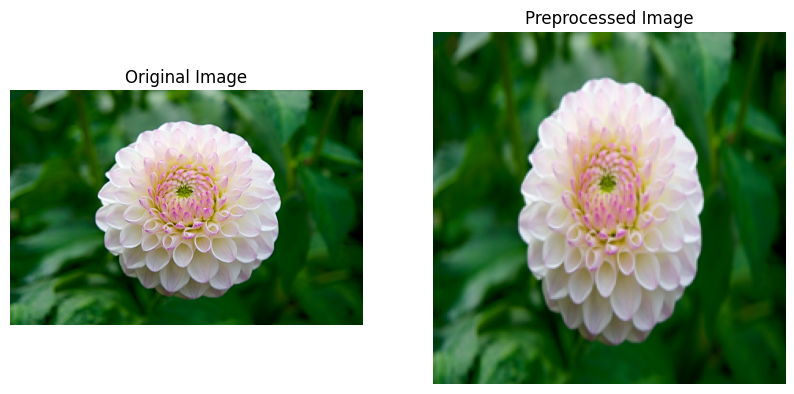

In [ ]:
import numpy as np
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

def preprocess_and_display_image(image_path, image_size=(224, 224)):
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    try:
        # Load and display the original image
        image = Image.open(image_path).convert('RGB')
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title('Original Image')
        plt.axis('off')

        # Preprocess the image
        preprocessed_image = transform(image)
        print("Image successfully preprocessed.")

        # Convert back to image for visualization
        unnormalize = transforms.Compose([
            transforms.Normalize(mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                                   std=[1 / 0.229, 1 / 0.224, 1 / 0.225]),
            transforms.ToPILImage()
        ])
        display_image = unnormalize(preprocessed_image)

        # Display the preprocessed image
        plt.subplot(1, 2, 2)
        plt.imshow(display_image)
        plt.title('Preprocessed Image')
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error processing image: {e}")

# Example usage
image_path = '/content/flower.jpg'
preprocess_and_display_image(image_path)

ViT

Image successfully preprocessed for ViT.


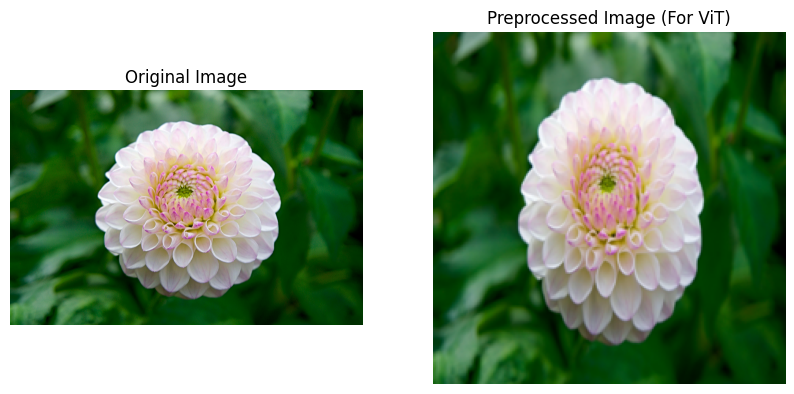

In [ ]:
import numpy as np
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

def preprocess_and_display_image(image_path, image_size=(224, 224)):
    # Preprocessing for ViT (Vision Transformer)
    transform = transforms.Compose([
        transforms.Resize(image_size),  # ViT typically uses 224x224 input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
    ])

    try:
        # Load and display the original image
        image = Image.open(image_path).convert('RGB')
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title('Original Image')
        plt.axis('off')

        # Preprocess the image
        preprocessed_image = transform(image)
        print("Image successfully preprocessed for ViT.")

        # Convert back to image for visualization
        unnormalize = transforms.Compose([
            transforms.Normalize(mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                                   std=[1 / 0.229, 1 / 0.224, 1 / 0.225]),
            transforms.ToPILImage()
        ])
        display_image = unnormalize(preprocessed_image)

        # Display the preprocessed image
        plt.subplot(1, 2, 2)
        plt.imshow(display_image)
        plt.title('Preprocessed Image (For ViT)')
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error processing image: {e}")

# Example usage
image_path = '/content/flower.jpg'
preprocess_and_display_image(image_path)


SWIN TRANSFORMER(Extracting patches)

Image successfully preprocessed for Swin Transformer.
Extracted 3136 patches of size 4x4


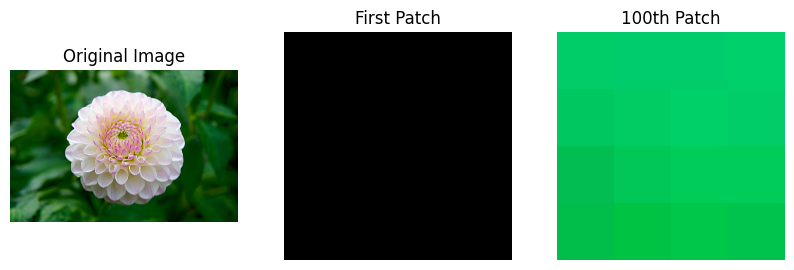

In [ ]:
import numpy as np
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn as nn

def preprocess_and_display_image(image_path, image_size=(224, 224), patch_size=4):
    # Preprocessing for Swin Transformer
    transform = transforms.Compose([
        transforms.Resize(image_size),  # Swin Transformer typically uses 224x224 input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet normalization
    ])

    try:
        # Load and display the original image
        image = Image.open(image_path).convert('RGB')
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(image)
        plt.title('Original Image')
        plt.axis('off')

        # Preprocess the image
        preprocessed_image = transform(image).unsqueeze(0)
        print("Image successfully preprocessed for Swin Transformer.")

        # Simulate patch extraction (Swin Transformer uses non-overlapping patches)
        unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
        patches = unfold(preprocessed_image)
        num_patches = patches.shape[-1]
        print(f"Extracted {num_patches} patches of size {patch_size}x{patch_size}")

        # Visualize a few patches (reshaped to image-like representation)
        patch_images = patches[0].reshape(3, patch_size, patch_size, -1).permute(3, 1, 2, 0)
        plt.subplot(1, 3, 2)
        plt.imshow(patch_images[0].numpy())
        plt.title('First Patch')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(patch_images[100].numpy())
        plt.title('100th Patch')
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error processing image: {e}")

# Example usage
image_path = '/content/flower.jpg'
preprocess_and_display_image(image_path)
